In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Bengin case (14).jpg to Bengin case (14).jpg


In [ ]:
import torch
import torchvision as tv
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

# Path to test CT image
IMAGE_PATH = "/content/Bengin case (14).jpg"

# Save location
SAVE_DIR = "/content/drive/MyDrive/results/gradcam_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)


In [ ]:
model = tv.models.efficientnet_b1(
    weights=tv.models.EfficientNet_B1_Weights.IMAGENET1K_V1
).to(device)

model.eval()


Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 136MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    return img, img_tensor


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = torch.relu(cam)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = cv2.resize(cam, (240,240))
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam


In [ ]:
# Last convolution block of EfficientNet-B1
target_layer = model.features[-1]

gradcam = GradCAM(model, target_layer)

orig_img, img_tensor = load_image(IMAGE_PATH)

cam = gradcam.generate(img_tensor)


In [ ]:
def overlay_cam(image, cam):
    image = np.array(image.resize((240,240)))
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam), cv2.COLORMAP_JET
    )
    overlay = cv2.addWeighted(image, 0.6, heatmap, 0.4, 0)
    return overlay


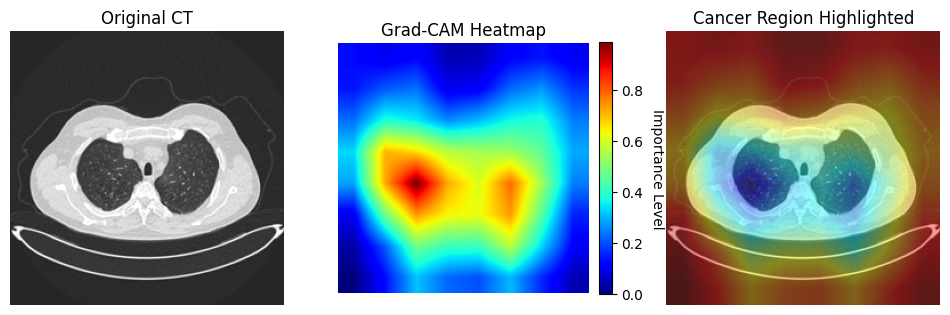

Grad-CAM Color Interpretation:
🔴 Red    : Highly affected / strongest cancer-related region
🟡 Yellow : Moderately affected region
🟢 Green  : Low contribution region
🔵 Blue   : Normal or non-relevant region

Saved at: /content/drive/MyDrive/results/gradcam_outputs/GradCAM_EfficientNetB1.png


In [ ]:
overlay_img = overlay_cam(orig_img, cam)

plt.figure(figsize=(12,4))

# -------- Original CT --------
plt.subplot(1,3,1)
plt.imshow(orig_img.resize((240,240)), cmap="gray")
plt.title("Original CT")
plt.axis("off")

# -------- Grad-CAM Heatmap --------
plt.subplot(1,3,2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM Heatmap")

# 🔥 Color legend (importance scale)
cbar = plt.colorbar(fraction=0.046, pad=0.04)
cbar.set_label("Importance Level", rotation=270, labelpad=15)
plt.axis("off")

# -------- Overlay --------
plt.subplot(1,3,3)
plt.imshow(overlay_img)
plt.title("Cancer Region Highlighted")
plt.axis("off")

# -------- Save --------
save_path = os.path.join(SAVE_DIR, "GradCAM_EfficientNetB1.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

# -------- Text Explanation --------
print("Grad-CAM Color Interpretation:")
print("🔴 Red    : Highly affected / strongest cancer-related region")
print("🟡 Yellow : Moderately affected region")
print("🟢 Green  : Low contribution region")
print("🔵 Blue   : Normal or non-relevant region")

print("\nSaved at:", save_path)
